In [4]:
import tensorflow as tf
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

In [21]:
# Config
IMG_SIZE = (50, 50)
BATCH_SIZE = 200
AUTOTUNE = tf.data.AUTOTUNE

# 1) Crear dataset con rutas + etiqueta
ds_normal = tf.data.Dataset.list_files('./imagenes/train/NORMAL/*.jpeg')
ds_normal = ds_normal.map(lambda p: (p, 0))

ds_pneumonia = tf.data.Dataset.list_files('./imagenes/train/PNEUMONIA/*.jpeg')
ds_pneumonia = ds_pneumonia.map(lambda p: (p, 1))

dataset = ds_normal.concatenate(ds_pneumonia)

ds_val_normal = tf.data.Dataset.list_files('./imagenes/val/NORMAL/*.jpeg')
ds_val_normal = ds_val_normal.map(lambda p: (p, 0))

ds_val_pneumonia = tf.data.Dataset.list_files('./imagenes/val/PNEUMONIA/*.jpeg')
ds_val_pneumonia = ds_val_pneumonia.map(lambda p: (p, 1))

# 2) Cargar y preparar imagen
def preprocess(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=1)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255
    return img, label

dataset = dataset.map(preprocess)
val_dataset = ds_val_normal.concatenate(ds_val_pneumonia).map(preprocess)

# 3) shuffle + batch + prefetch
dataset = dataset.shuffle(5216).batch(BATCH_SIZE).prefetch(AUTOTUNE)
val_dataset = val_dataset.batch(BATCH_SIZE).prefetch(AUTOTUNE)

print(dataset.element_spec)

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(50, 50, 1)),

    tf.keras.layers.Conv2D(32, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Conv2D(64, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.summary()

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss',
                                        patience=5)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.2,   # Reduce by 80% (new_lr = lr * 0.2)
    patience=3,   # Wait 5 epochs
    min_lr=0.0001,
    verbose=1
)

model.fit(dataset, epochs=50, validation_data=val_dataset, callbacks=[stop, reduce_lr])


resultados = model.evaluate(dataset, return_dict=True)
print(resultados)

(TensorSpec(shape=(None, 50, 50, 1), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))


Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_33 (Conv2D)              │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_33 (MaxPooling2D) │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_46 (Dropout)            │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_34 (Conv2D)              │ (None, 22, 22, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_34 (MaxPooling2D) │ (None, 11, 11, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_47 (Dropout)            │ (None, 11, 11, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_16 (Flatten)            │ (None, 7744)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 128)            │       991,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_48 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,010,305 (3.85 MB)

 Trainable params: 1,010,305 (3.85 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 7s 86ms/step - accuracy: 0.7283 - loss: 0.5889 - val_accuracy: 0.5000 - val_loss: 0.6891 - learning_rate: 0.0010
Epoch 2/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 84ms/step - accuracy: 0.7602 - loss: 0.4611 - val_accuracy: 0.6250 - val_loss: 0.6149 - learning_rate: 0.0010
Epoch 3/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 83ms/step - accuracy: 0.8211 - loss: 0.3245 - val_accuracy: 0.6250 - val_loss: 0.5751 - learning_rate: 0.0010
Epoch 4/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 6s 100ms/step - accuracy: 0.8800 - loss: 0.2630 - val_accuracy: 0.7500 - val_loss: 0.5558 - learning_rate: 0.0010
Epoch 5/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 6s 96ms/step - accuracy: 0.9001 - loss: 0.2350 - val_accuracy: 0.8125 - val_loss: 0.4924 - learning_rate: 0.0010
Epoch 6/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 6s 88ms/step - accuracy: 0.9174 - loss: 0.2152 - val_accuracy: 0.8750 - val_loss: 0.4656 - learning_rate: 0.0010
Epoch 7/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 6s 85ms/step - accuracy: 0.9224 - loss: 0.2176 - val_ac

In [ ]:
pred = model.predict(dataset)

from sklearn.metrics import confusion_matrix

y_pred = (pred >= 0.5).astype(int).flatten()

# 3. Obtener etiquetas verdaderas
y_true = []
for _, label in dataset.unbatch():
    y_true.append(int(label.numpy()))
y_true = np.array(y_true)

# 4. Calcular matriz de confusión
cm = confusion_matrix(y_true, y_pred)
print("Matriz de confusión:\n", cm)

# TODO: Revisar ConfusionMatrixDisplay para mostrar la matriz de confusión de forma gráfica

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step
Matriz de confusión:
 [[ 96 138]
 [147 243]]


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━

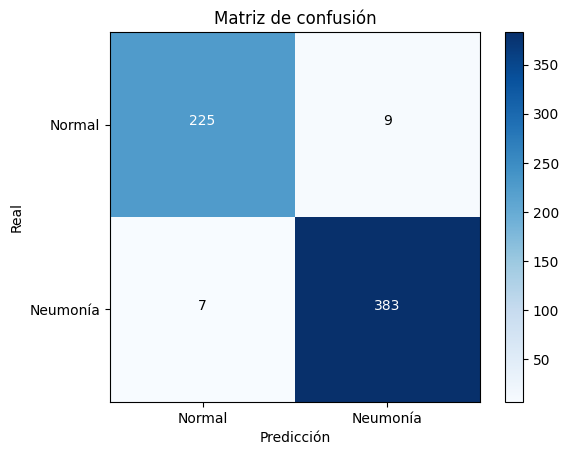

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import itertools

# 1. Obtener imágenes y etiquetas verdaderas del dataset
y_true = []
y_pred = []

for images, labels in dataset.unbatch():
    img = tf.expand_dims(images, axis=0)  # Añadir dimensión batch
    pred = model.predict(img)
    y_pred.append(1 if pred[0][0] >= 0.5 else 0)
    y_true.append(int(labels.numpy()))

print(y_pred)

# 2. Calcular matriz de confusión
cm = confusion_matrix(y_true, y_pred)

# 3. (Opcional) Visualizar la matriz de confusión
plt.imshow(cm, cmap=plt.cm.Blues)
plt.title("Matriz de confusión")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.colorbar()
plt.xticks([0,1], ["Normal", "Neumonía"])
plt.yticks([0,1], ["Normal", "Neumonía"])

# Añadir los números en la matriz
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, cm[i, j], horizontalalignment="center", color="white" if cm[i, j] > cm.max()/2 else "black")

plt.show()

##### Explicar como resuelve el problema la capa de salida.

La salida nos da el porcentaje de que la imagen tenga neumonía(clase 1) y el porcentaje restante es la probabilidad de que no la tenga(clase 0).

##### ¿Por qué el model actual tiene esa arquitectura y número de parametros?

Al ser un problema binario, lo mas importate es que la capa de salida tenga una neurona con activación sigmoide, para que nos de un resultado entre 0 y 1. El resto de la arquitectura es bastante común para problemas de clasificación de imágenes, con varias capas convolucionales seguidas de capas de pooling para reducir el tamaño.

##### Explicar que pasa con el val y el val_loss

El val_loss baja hasta hasta mantenerse entre 0.5 y 0.7, y el val baja hasta 0.75 y a partir de ahí se mantiene.

##### ¿Qué habeis hecho para evitar el overfitting y como os habeis asegurado de ello?



##### ¿Qué tal os va el modelo con el "test de la calle"?